### CS 180 Machine Exercise 6: Unsupervised Learning

This exercise uses **Wholesale Customers Dataset** from the UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/292/wholesale+customers). It contains annual spending data across several product categories for 440 clients.

**The Scenario**

You are a data analyst for a wholesale distributor. The marketing team wants to transition from "one-size-fits-all" promotions to targeted campaigns. Your task is to group customers into clusters based on their spending habits and determine the "optimal" number of groups using Silhouette Analysis.



**Part 1: The Programming Task** (70 points)

**Prerequisites**

You will need pandas, numpy, matplotlib, seaborn, and sklearn.

**Instructions**

1.   Load the Data: Use the URL: https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv
2.   Pre-processing: Drop the Channel and Region columns (these are categorical labels, not spending metrics).
3. Scale the data: K-Means is sensitive to magnitude. Use StandardScaler.
4. Clustering: Loop through $k$ values from 2 to 6.
5. Evaluation: For each $k$, calculate the Silhouette Score.
6. Display the graph of number of clusters vs silhouette coefficient





For n_clusters =  2 The silhouette score is : 0.7366531238216748
For n_clusters =  3 The silhouette score is : 0.33391714199926514
For n_clusters =  4 The silhouette score is : 0.36232371550681225
For n_clusters =  5 The silhouette score is : 0.31495888766416014
For n_clusters =  6 The silhouette score is : 0.30404895370073115


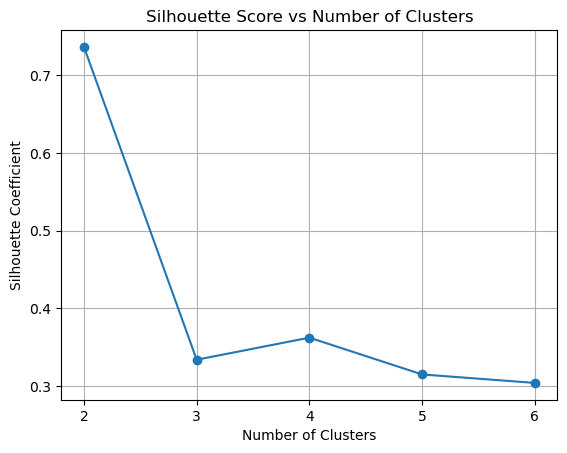

In [6]:
# Write your code here
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns;
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load the Data 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

# Pre-process
# Drop Channel and Region columns
df = df.drop(columns=['Channel', 'Region'])

# Scale the Data using Standard Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Clustering and Evaluation
k_values = range(2, 7)
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=180)
    y_kmeans = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, y_kmeans)
    silhouette_scores.append(silhouette_avg)

    print(
        "For n_clusters = ",
        k,
        "The silhouette score is :",
        silhouette_avg
    )

# Graph (num of clusters vs. silhouette coefficient)
plt.figure()
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(k_values)
plt.grid()
plt.show(0)


**Part 2: Understanding the Output** (30 points)

Read about [silhouette analysis](http://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html) in the sklearn documentation.

The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to +1:

+1: High consistency; clusters are well apart and clearly defined.

0: Overlapping clusters.

-1: Samples assigned to the wrong cluster.

After running the code, answer the following questions to deepen your understanding:

Critical Thinking Questions

1. **The "Best" K**: Based on your plot, which value of $k$ produced the highestSilhouette Score? Does this necessarily mean it's the most "useful" number of segments for a business?
2. **Interpretation of clusters**: How would you interpret the resulting clusters?

3. **Impact of Scaling**: If you comment out the StandardScaler step and re-run the analysis, what happens to the results? Why does K-Means struggle with unscaled data in this specific dataset?

Explain your answer here:
1.) The value of k=2 produced the highestSilhouette Score. However, this does not necessarily mean it is the most useful number of segments for a business. It just shows how well-separated the clusters are to each other. In our business case, since we want to categorize our customers, it may not be ideal to just have 2 types of customers since it can be a bit too broad.

2.) Interpreting the highest Silhouette score with k=2, could mean that the customers are mainly classified to high spenders and low spenders across all the 6 categories (Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen). The other clusters of 3-6 could potentially find a new way to segragate the customers' spending habits in a more concentrated way, but their resulting silhouette scores are low compared to k=2. K=6 could be an attempt in categorizing the customers based on the 6 spending sections.



For n_clusters =  2 The silhouette score is : 0.6040916077698741
For n_clusters =  3 The silhouette score is : 0.3460113472434008
For n_clusters =  4 The silhouette score is : 0.4063714868284033
For n_clusters =  5 The silhouette score is : 0.37181773295430853
For n_clusters =  6 The silhouette score is : 0.29931063317788353


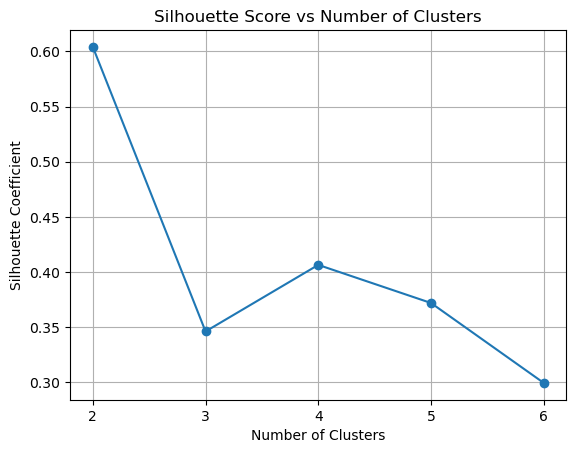

In [10]:
# 3.) Impact of Scaling (Comment out StandardScaler)

### COMMENTED OUT ###
# Scale the Data using Standard Scaler
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(df)
#####################

# Clustering and Evaluation
k_values = range(2, 7)
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=180)
    y_kmeans = kmeans.fit_predict(df)
    silhouette_avg = silhouette_score(df, y_kmeans)
    silhouette_scores.append(silhouette_avg)

    print(
        "For n_clusters = ",
        k,
        "The silhouette score is :",
        silhouette_avg
    )

# Graph (num of clusters vs. silhouette coefficient)
plt.figure()
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(k_values)
plt.grid()
plt.show(1)

3.) The code above shows the result when StandardScaler is not used. Clearly, the silhouette scores completely differ from the scaled version, however, the trend still persists with a bit more unstability. The highest silhouette score is still k=2 and it drops after with k=3-6. However, the biggest difference is the drop of the Silhouette score with a lower 0.60 compared to the 0.73 previously. The reason why KMeans struggle with unstandardized data is because of the distance function that it uses such that larger values will dominate and overshadow the distance. Without proper scaling, large numbers will take dictate the importance of a feature and group them accordingly instead of having a fair and equal treatment to each column feature.